# TASK 3 |
# MINI EDA ON TITANIC DATASET



In [ ]:
# Importing the libraries and dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Titanic-Dataset.csv")

# CLEAN THE DATASET

In [ ]:
# Fill missing Age values with the mean

In [ ]:
df["Age"].fillna(df["Age"].mean(),inplace=True)
display(df["Age"])

/tmp/ipykernel_31361/1385597369.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].mean(),inplace=True)


,Age
0,22.000000
1,38.000000
2,26.000000
3,35.000000
4,35.000000
...,...
886,27.000000
887,19.000000
888,29.699118
889,26.000000


In [ ]:
# Drop the Cabin column

In [ ]:
df.drop(columns=["Cabin"],inplace=True)

# Create New Feature

In [ ]:
# Create new AgeGroup

In [14]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0,12,18,30,50,80],
    labels=["child","teen","young adult","adult","senior"]
)
display(df["AgeGroup"])

,AgeGroup
0,young adult
1,adult
2,young adult
3,adult
4,adult
...,...
886,young adult
887,young adult
888,young adult
889,young adult


In [ ]:
# Create family size

In [16]:
df["FamilySize"]=df['SibSp']+df['Parch']
print(df['FamilySize'])

0      1
1      1
2      0
3      1
4      0
      ..
886    0
887    0
888    3
889    0
890    0
Name: FamilySize, Length: 891, dtype: int64


# Answering the Questions

In [ ]:
# Survival Rate by Age Group

In [33]:
print(df.groupby("AgeGroup")["Survived"].mean())

AgeGroup
child          0.579710
teen           0.428571
young adult    0.331096
adult          0.423237
senior         0.343750
Name: Survived, dtype: float64


/tmp/ipykernel_31361/1657910713.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("AgeGroup")["Survived"].mean())


In [ ]:
# Survival Rate by Embarkation Port

In [19]:
print(df.groupby("Embarked")["Survived"].mean())

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


In [ ]:
# Survival Rate by Family Size

In [21]:
print(df.groupby("FamilySize")["Survived"].sum())

FamilySize
0     163
1      89
2      59
3      21
4       3
5       3
6       4
7       0
10      0
Name: Survived, dtype: int64


# Create Visualizations

In [ ]:
# Histogram of Age Distribution

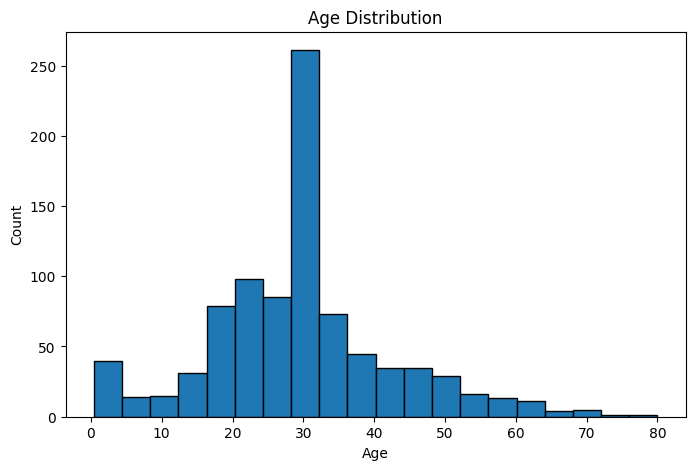

In [29]:
plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=20,edgecolor="black")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

In [ ]:
# Correlation Heatmap

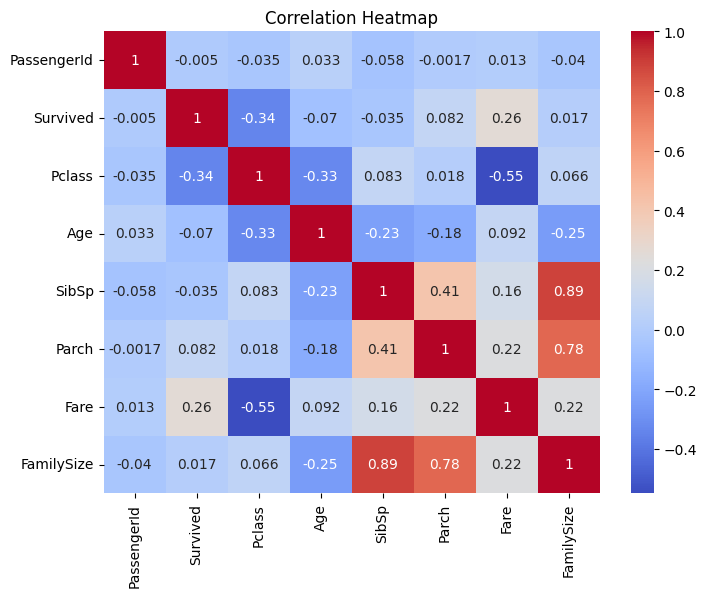

In [25]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Survival by Family Size

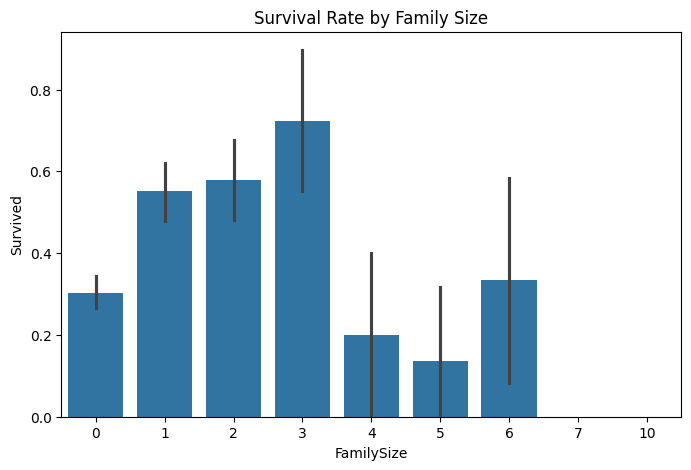

In [32]:
plt.figure(figsize=(8,5))
sns.barplot(x="FamilySize", y="Survived", data=df)
plt.title("Survival Rate by Family Size")
plt.show()

# Observation

In [ ]:
# Age Distribution
#-Most passengers were between 20 and 40 years old.
#-Very few passengers were older than 60.
# Age Group Survival
#-Childrens had a higher survival rate.
#-Adults had a lower survival rate than Adult.
# Embarkation Port
#-Passengers from one embarkation port may have had a higher survival rate than others.
# Family Size
#-Small families had a better survival rate than very large families.
# Correlation Heatmap
#-Passenger class and fare show relationships with survival.
#-Family-related features have weaker correlations.